# dup_stat — интерактивная демонстрация

Ноутбук показывает, как использовать пакет `dup_stat` для поиска
файлов-дубликатов: программно (без CLI), с выводом в виде таблицы
`pandas.DataFrame` и графиком "лишнего" занятого места по группам.

Перед запуском активируйте виртуальное окружение проекта:

```bash
source .venv/bin/activate
jupyter notebook notebooks/dup_stat_demo.ipynb
```


In [1]:
import sys
from pathlib import Path

# Позволяет импортировать пакет dup_stat из корня репозитория,
# если ноутбук запущен не через `pip install -e .`, а напрямую.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dup_stat.finder import DuplicateFinder
from dup_stat.hashing import HashlibFileHasher
from dup_stat.matching import create_strategy
from dup_stat.scanning import RecursiveFileScanner
from dup_stat.utils import human_readable_size

import pandas as pd
import matplotlib.pyplot as plt

print("dup_stat загружен из:", project_root)


dup_stat загружен из: /home/user/dup_stat


## 1. Готовим тестовую директорию с дубликатами

Создаём временную структуру файлов: несколько групп с одинаковым
содержимым (в разных подпапках и под разными именами) и пару
уникальных файлов.

In [2]:
import tempfile

demo_dir = Path(tempfile.mkdtemp(prefix="dup_stat_demo_"))
(demo_dir / "docs").mkdir()
(demo_dir / "backup").mkdir()

samples = {
    "report.txt": b"Quarterly report content, version 1\n" * 50,
    "docs/report_copy.txt": b"Quarterly report content, version 1\n" * 50,
    "backup/report.txt": b"Quarterly report content, version 1\n" * 50,
    "photo.jpg": b"\xff\xd8\xfake-jpeg-bytes" * 200,
    "backup/photo_backup.jpg": b"\xff\xd8\xfake-jpeg-bytes" * 200,
    "notes.txt": b"These notes are one of a kind.",
    "docs/other_notes.txt": b"Completely different notes here.",
}

for rel_path, content in samples.items():
    path = demo_dir / rel_path
    path.write_bytes(content)

print("Демо-директория:", demo_dir)
for p in sorted(demo_dir.rglob("*")):
    if p.is_file():
        print(" ", p.relative_to(demo_dir), f"({p.stat().st_size} байт)")


Демо-директория: /tmp/dup_stat_demo_yu2ecgnz
  backup/photo_backup.jpg (3200 байт)
  backup/report.txt (1800 байт)
  docs/other_notes.txt (32 байт)
  docs/report_copy.txt (1800 байт)
  notes.txt (30 байт)
  photo.jpg (3200 байт)
  report.txt (1800 байт)


## 2. Запускаем поиск дубликатов

Собираем `DuplicateFinder` из трёх независимых компонентов —
сканера директории, хешера и стратегии сравнения (Dependency
Injection). По умолчанию дубликатами считаются файлы с одинаковым
содержимым (SHA-256), независимо от имени.

In [3]:
finder = DuplicateFinder(
    scanner=RecursiveFileScanner(),
    hasher=HashlibFileHasher(algorithm="sha256"),
    key_strategy=create_strategy("hash"),
)

groups = finder.find(demo_dir)
print(f"Найдено групп дубликатов: {len(groups)}")


Найдено групп дубликатов: 2


## 3. Таблица результатов (pandas)

In [4]:
rows = []
for i, group in enumerate(sorted(groups, key=lambda g: g.wasted_size, reverse=True), start=1):
    for record in group.records:
        rows.append({
            "group": i,
            "hash": record.file_hash[:12] + "...",
            "path": str(record.path.relative_to(demo_dir)),
            "size_bytes": record.size,
        })

df = pd.DataFrame(rows)
df


,group,hash,path,size_bytes
0,1,e347d3635842...,docs/report_copy.txt,1800
1,1,e347d3635842...,report.txt,1800
2,1,e347d3635842...,backup/report.txt,1800
3,2,253443976c62...,photo.jpg,3200
4,2,253443976c62...,backup/photo_backup.jpg,3200


## 4. Сводка по группам и общий размер лишних копий

In [5]:
summary = (
    df.groupby("group")
    .agg(files=("path", "count"), size_bytes=("size_bytes", "first"))
    .assign(wasted_bytes=lambda d: d["size_bytes"] * (d["files"] - 1))
    .sort_values("wasted_bytes", ascending=False)
)
summary


,files,size_bytes,wasted_bytes
group,,,
1,3,1800,3600
2,2,3200,3200


In [6]:
total_wasted = sum(g.wasted_size for g in groups)
print(f"Суммарный размер лишних копий: {human_readable_size(total_wasted)} ({total_wasted} байт)")


Суммарный размер лишних копий: 6.64 KB (6800 байт)


## 5. График: сколько места можно освободить по каждой группе

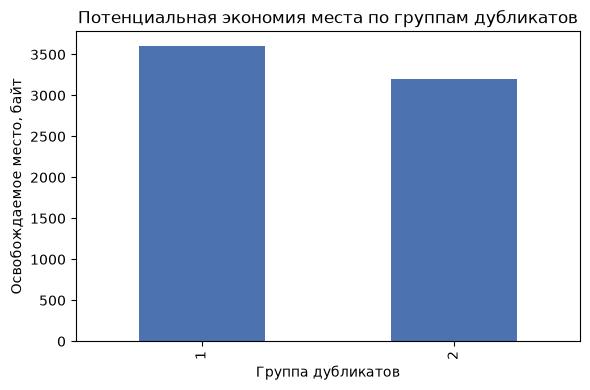

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
summary["wasted_bytes"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Группа дубликатов")
ax.set_ylabel("Освобождаемое место, байт")
ax.set_title("Потенциальная экономия места по группам дубликатов")
plt.tight_layout()
plt.show()


## 6. Сравнение критериев совпадения

`dup_stat` позволяет уточнить, что считать дубликатом, не только по
содержимому, но и с учётом имени файла (см. `dup_stat/matching.py`).
Ниже видно, что при критерии `hash+name` файл `backup/report.txt`
(то же содержимое, то же имя) остаётся в группе, а `docs/report_copy.txt`
(то же содержимое, другое имя) — уже нет.

In [8]:
for preset in ("hash", "hash+name", "hash+name+size"):
    strict_finder = DuplicateFinder(
        scanner=RecursiveFileScanner(),
        hasher=HashlibFileHasher(algorithm="sha256"),
        key_strategy=create_strategy(preset),
    )
    strict_groups = strict_finder.find(demo_dir)
    total = sum(g.wasted_size for g in strict_groups)
    print(f"{preset:>16}: групп={len(strict_groups)}, "
          f"лишних байт={total} ({human_readable_size(total)})")


            hash: групп=2, лишних байт=6800 (6.64 KB)
       hash+name: групп=1, лишних байт=1800 (1.76 KB)
  hash+name+size: групп=1, лишних байт=1800 (1.76 KB)


## 7. Уборка временной директории

In [9]:
import shutil
shutil.rmtree(demo_dir)
print("Удалено:", demo_dir)


Удалено: /tmp/dup_stat_demo_yu2ecgnz


## 8. Сохранение результатов локально (SQLite + pandas.DataFrame)

`dup_stat.storage.ResultPersistence` сохраняет результаты сразу в двух
локальных форматах — SQLite и pandas `DataFrame` (pickle) — с **одним и
тем же timestamp** в имени файла, чтобы результаты одного прогона было
легко сопоставить.

In [10]:
import sqlite3
from dup_stat.storage import DataFrameResultExporter, ResultPersistence, SqliteResultExporter

# Пересоздаём демо-директорию, т.к. предыдущая ячейка её удалила
demo_dir = Path(tempfile.mkdtemp(prefix="dup_stat_demo_"))
(demo_dir / "docs").mkdir()
(demo_dir / "backup").mkdir()
for rel_path, content in samples.items():
    (demo_dir / rel_path).write_bytes(content)

groups = finder.find(demo_dir)

save_dir = demo_dir / "results"
persistence = ResultPersistence([SqliteResultExporter(), DataFrameResultExporter()])
saved_paths = persistence.save_all(groups, save_dir)
for p in saved_paths:
    print("Сохранено:", p.name)


Сохранено: dup_stat_results_20260823_053104.sqlite3
Сохранено: dup_stat_results_20260823_053104.pkl


In [11]:
sqlite_path = next(p for p in saved_paths if p.suffix == ".sqlite3")
pkl_path = next(p for p in saved_paths if p.suffix == ".pkl")

# Одинаковый timestamp в обоих именах файлов
assert sqlite_path.stem.split("dup_stat_results_")[1] == pkl_path.stem.split("dup_stat_results_")[1]

with sqlite3.connect(sqlite_path) as conn:
    sqlite_df = pd.read_sql("SELECT * FROM duplicate_files", conn)
sqlite_df


,group_id,file_hash,path,name,size_bytes,mtime,wasted_bytes
0,1,e347d3635842b1d0819b585062849950d5741909e3de4d...,/tmp/dup_stat_demo_8rwxxtbt/docs/report_copy.txt,report_copy.txt,1800,1.787463e+09,3600
1,1,e347d3635842b1d0819b585062849950d5741909e3de4d...,/tmp/dup_stat_demo_8rwxxtbt/backup/report.txt,report.txt,1800,1.787463e+09,3600
2,1,e347d3635842b1d0819b585062849950d5741909e3de4d...,/tmp/dup_stat_demo_8rwxxtbt/report.txt,report.txt,1800,1.787463e+09,3600
3,2,253443976c6221f96113a82ee2e1a58a97b5690eccaf79...,/tmp/dup_stat_demo_8rwxxtbt/backup/photo_backu...,photo_backup.jpg,3200,1.787463e+09,3200
4,2,253443976c6221f96113a82ee2e1a58a97b5690eccaf79...,/tmp/dup_stat_demo_8rwxxtbt/photo.jpg,photo.jpg,3200,1.787463e+09,3200


In [12]:
loaded_df = pd.read_pickle(pkl_path)
loaded_df


,group_id,file_hash,path,name,size_bytes,mtime,wasted_bytes
0,1,e347d3635842b1d0819b585062849950d5741909e3de4d...,/tmp/dup_stat_demo_8rwxxtbt/docs/report_copy.txt,report_copy.txt,1800,1.787463e+09,3600
1,1,e347d3635842b1d0819b585062849950d5741909e3de4d...,/tmp/dup_stat_demo_8rwxxtbt/backup/report.txt,report.txt,1800,1.787463e+09,3600
2,1,e347d3635842b1d0819b585062849950d5741909e3de4d...,/tmp/dup_stat_demo_8rwxxtbt/report.txt,report.txt,1800,1.787463e+09,3600
3,2,253443976c6221f96113a82ee2e1a58a97b5690eccaf79...,/tmp/dup_stat_demo_8rwxxtbt/backup/photo_backu...,photo_backup.jpg,3200,1.787463e+09,3200
4,2,253443976c6221f96113a82ee2e1a58a97b5690eccaf79...,/tmp/dup_stat_demo_8rwxxtbt/photo.jpg,photo.jpg,3200,1.787463e+09,3200


In [13]:
shutil.rmtree(demo_dir)
print("Удалено:", demo_dir)


Удалено: /tmp/dup_stat_demo_8rwxxtbt
